## Generate weight loss data

Week 0 = 115 kg
Week 1 = 

In [38]:
import numpy as np
from scipy.stats import norm, randint
import seaborn as sns
import pandas as pd

In [2]:
x = np.arange(0,16)
w = 115 - 1*x

w

array([115, 114, 113, 112, 111, 110, 109, 108, 107, 106, 105, 104, 103,
       102, 101, 100])

In [10]:
len(weeks)/4

5.0

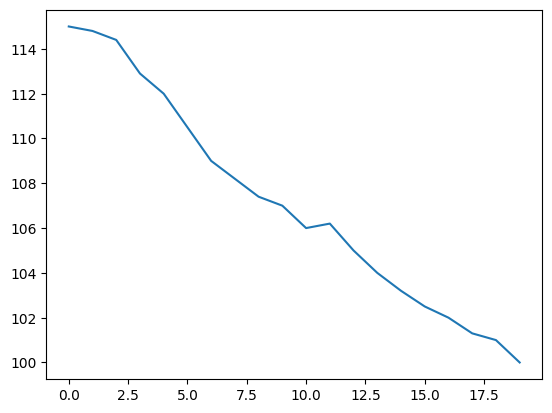

In [13]:
wbars = [115, 114.8, 114.4, 112.9, 112, 110.5,
         109, 108.2, 107.4, 107, 106, 106.2, 105,
         104, 103.2, 102.5, 102, 101.3, 101, 100]
week_ids = np.arange(0, len(wbars))
sns.lineplot(x=week_ids, y=wbars);

In [39]:
weeks = []
weights = []

np.random.seed(3)

for week_id, wbar in zip(week_ids, wbars):
    week_id = int(week_id)
    ndays = int(randint(10,40).rvs(1)[0])
    weeks.extend([week_id]*ndays)
    week_weights = norm(loc=wbar,scale=1.5).rvs(ndays).round(1)
    weights.extend(list(week_weights))

wloss = pd.DataFrame({"week": weeks, "weight": weights})
wloss

,week,weight
0,0,115.3
1,0,113.5
2,0,114.5
3,0,114.9
4,0,115.4
...,...,...
475,19,100.0
476,19,98.9
477,19,95.4
478,19,101.4


In [53]:
# wloss.to_csv("../datasets/wloss.csv", index=False)

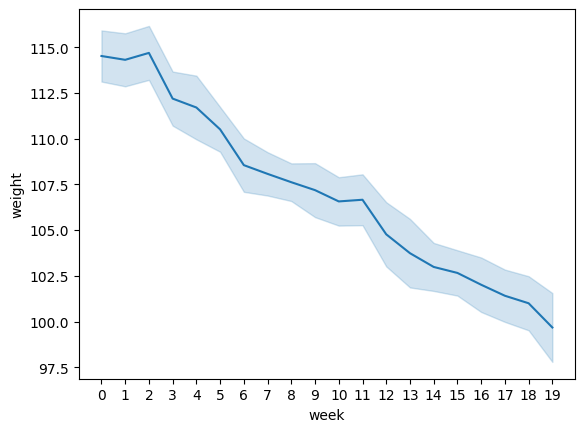

In [47]:
ax = sns.lineplot(data=wloss, x="week", y="weight", errorbar=("sd", 1))
ax.set_xticks(range(0,20));

In [51]:
import statsmodels.formula.api as smf

reg = smf.ols("weight ~ 1 + week", data=wloss).fit()
reg.params

Intercept    114.701931
week          -0.798754
dtype: float64

In [48]:
# ALT. Use linear algebra to fit linear model
import statsmodels.api as sm

x = wloss['week'].values
y = wloss['weight'].values
# add a column of ones to the x data
X = sm.add_constant(x)

result5 = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
beta0, beta1 = result5
beta0, beta1

(np.float64(114.70193088492428), np.float64(-0.7987536322892055))